# Data Preparation



In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

## Normalization

In [38]:
MAX_PREASSURE_LIMIT = 250 # mmHG

# Load the dataset
df = pd.read_csv("DatosEntrenamiento_DistProbTransEspacial_balanced.csv")

# Separate data and labels
labels = df["POSICION"].values
unique_labels = np.unique(labels)
data = df.drop(columns=["POSICION"]).values

# Find the max value for normalization
data_min = data.min()
data_max = data.max()
print(f"Data shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Data range: [{data_min.min():.4f}, {data_max.max():.4f}]")
print(f"Labels: {unique_labels}")

# Lets choose a fix max value based on our dataset (~236mmHg)
data_normalized = data / MAX_PREASSURE_LIMIT
print(f"Normalized range: [{data_normalized.min():.4f}, {data_normalized.max():.4f}]")

Data shape: (300000, 64)
Data type: float64
Data range: [0.0000, 233.4754]
Labels: ['fetus_L' 'fetus_R' 'prone' 'supine' 'trunk_L' 'trunk_R']
Normalized range: [0.0000, 0.9339]


## Quantization

Convert normalized float data to uint8 bits.

In [39]:
# Quantize the normalized data
data_q8 = np.round(data_normalized * 255).astype(np.uint8)

print(f"Q8 shape: {data_q8.shape}")
print(f"Q8 type: {data_q8.dtype}")
print(f"Q8 range: [{data_q8.min()}, {data_q8.max()}]")

Q8 shape: (300000, 64)
Q8 type: uint8
Q8 range: [0, 238]


### Quantization Error Analysis

In [40]:
# Quantization Error Analysis
dequantized = data_q8.astype(np.float32) / 255
abs_error = np.abs(data_normalized - dequantized)

print(f"Actual max error: {np.max(abs_error):.5f}")
print(f"Mean absolute error: {np.mean(abs_error):.5f}")

Actual max error: 0.00196
Mean absolute error: 0.00090


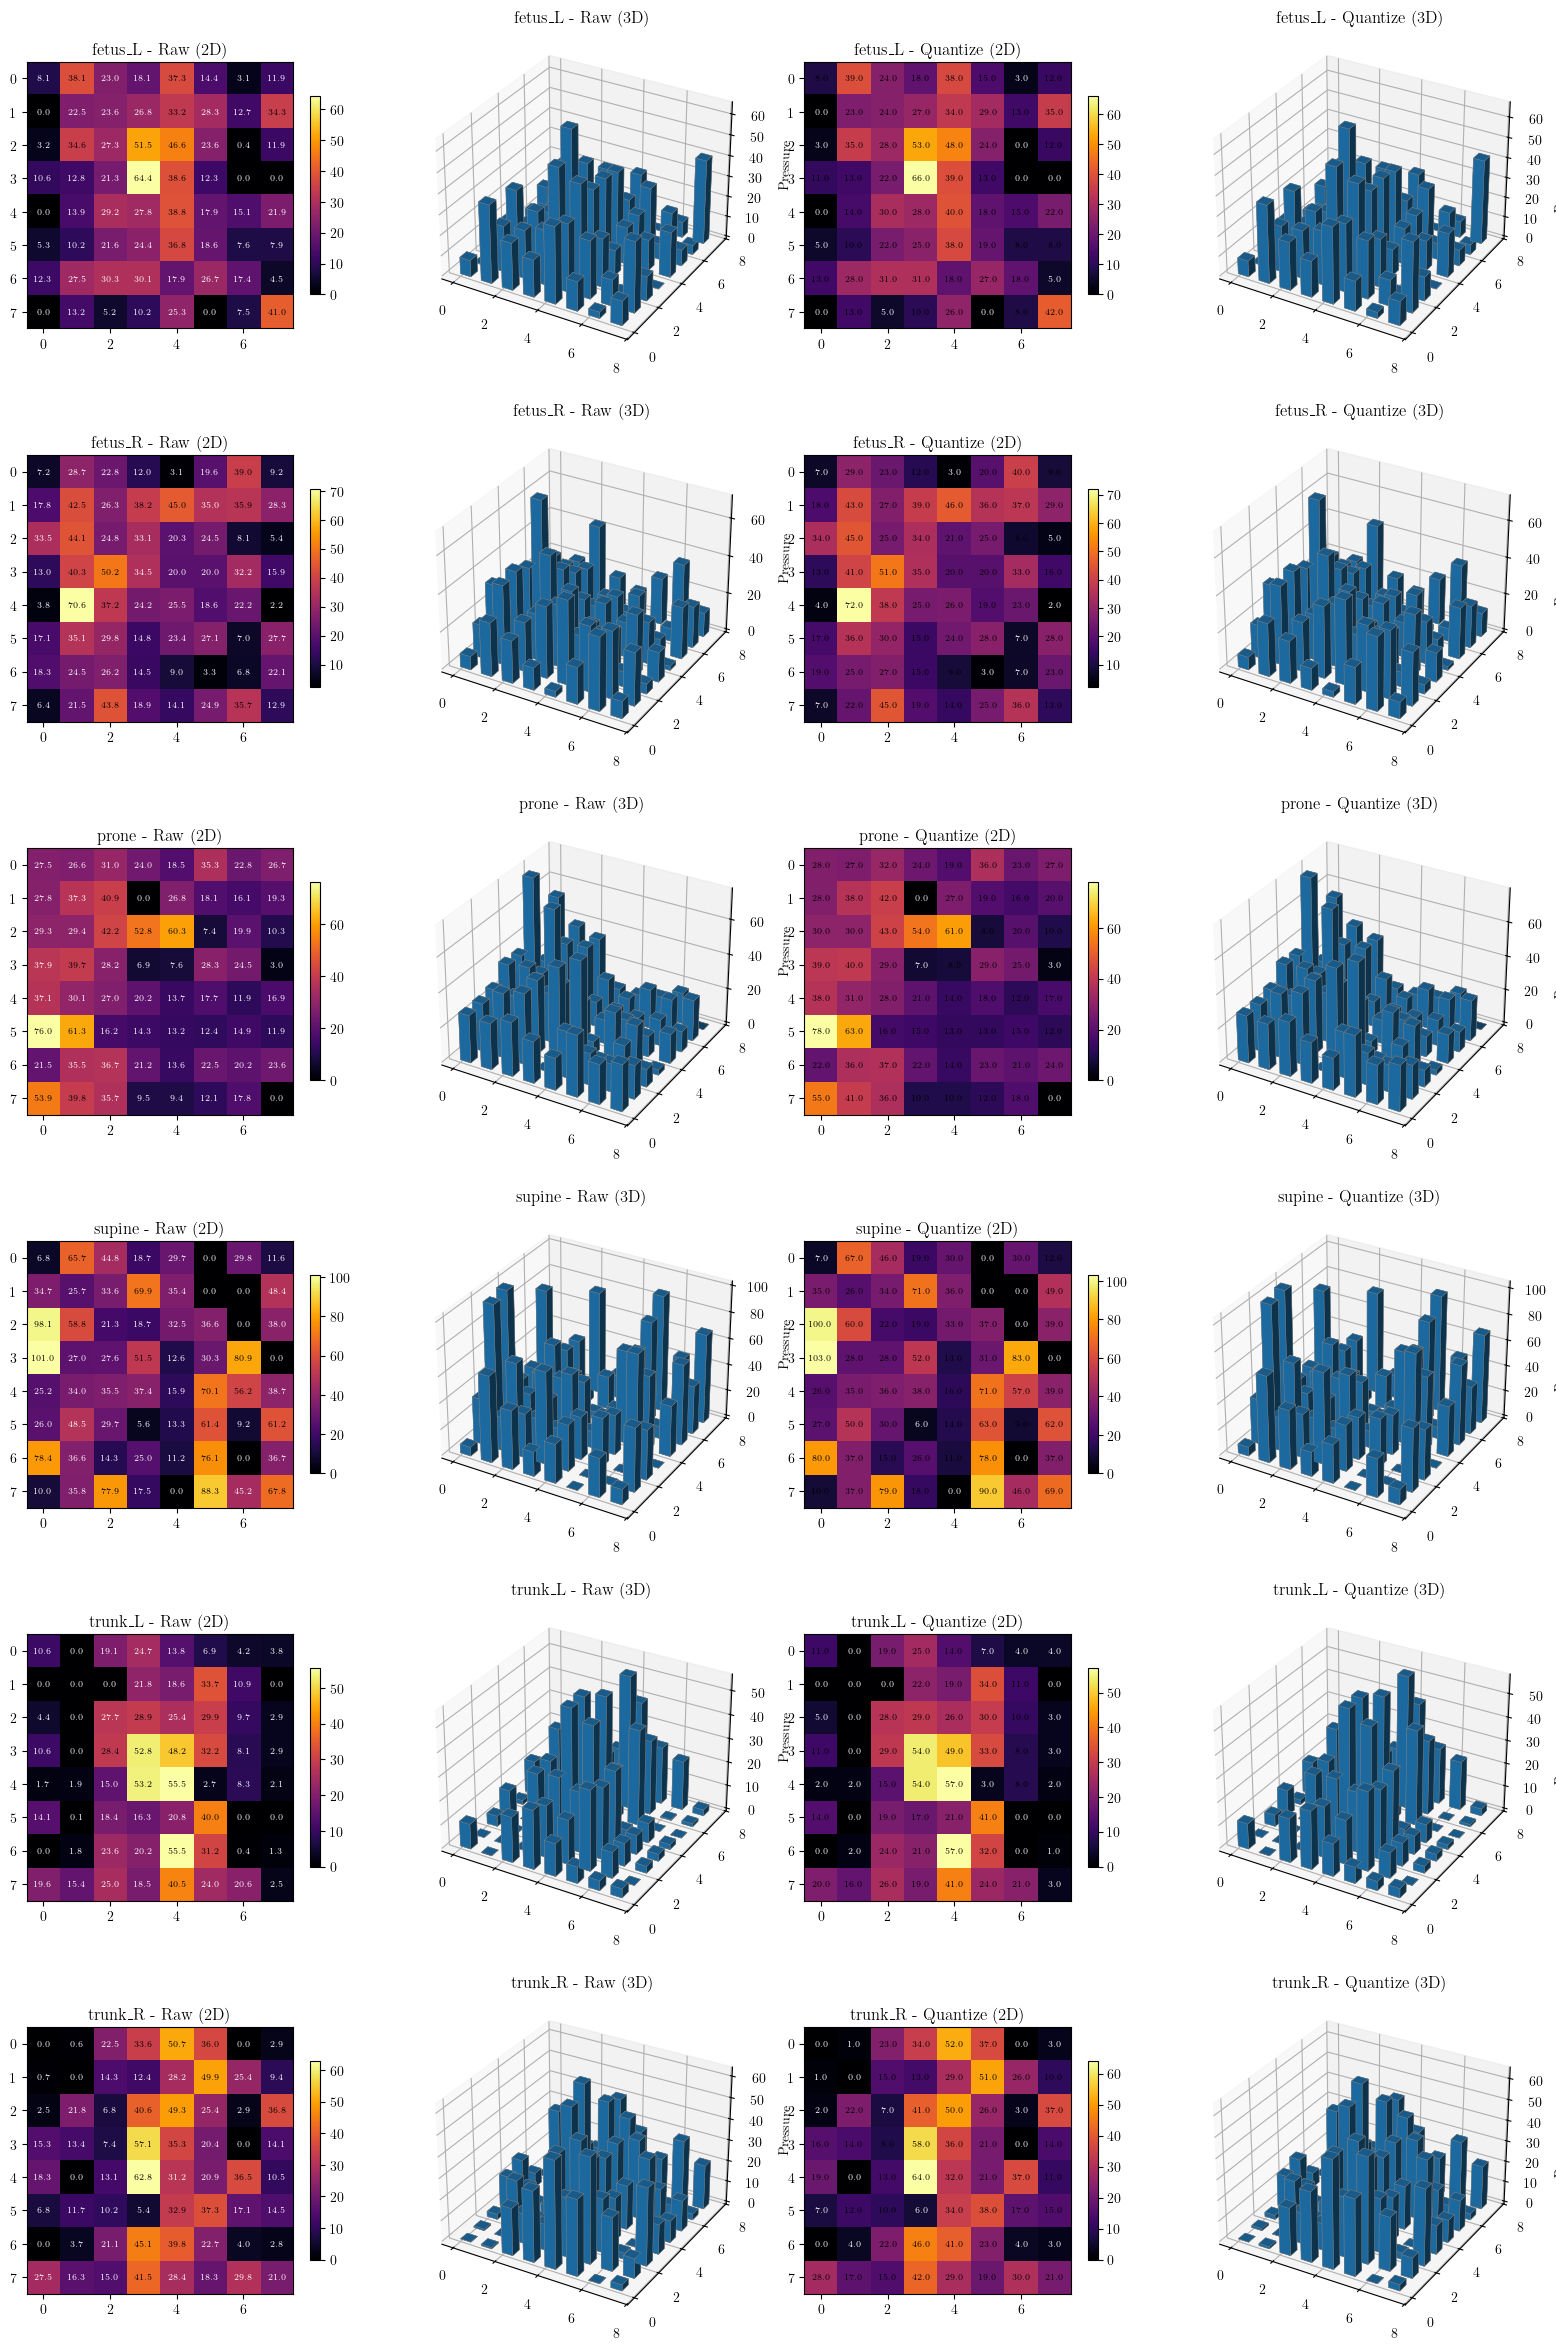

Saved: figures/all_samples_comparison.pdf


In [41]:
CMAP_STYLE = "inferno"

# Get one sample per unique label
sample_indices = [np.where(labels == label)[0][0] for label in unique_labels]

# Create figure: 6 labels × 2 states (raw/normQuant) × 2 plots (2D/3D)
fig = plt.figure(figsize=(16, 24))

for i, idx in enumerate(sample_indices):
    label = labels[idx]
    raw = data[idx].reshape(8, 8)
    normQuant = data_q8[idx].reshape(8, 8)
    
    # Row position for this label
    row = i * 2
    
    # --- Raw: 2D heatmap ---
    ax1 = fig.add_subplot(6, 4, row * 2 + 1)
    im1 = ax1.imshow(raw, cmap=CMAP_STYLE)
    ax1.set_title(f"{label} - Raw (2D)")
    for r in range(8):
        for c in range(8):
            color = "black" if raw[r, c] > raw.max() / 2 else "white"
            ax1.text(c, r, f"{raw[r, c]:.1f}", ha="center", va="center", color=color, fontsize=6)
    plt.colorbar(im1, ax=ax1, shrink=0.6)
    
    # --- Raw: 3D surface ---
    ax2 = fig.add_subplot(6, 4, row * 2 + 2, projection="3d")
    
    X, Y = np.meshgrid(range(8), range(8))
    x_pos = X.ravel()
    y_pos = Y.ravel()
    z_pos = np.zeros_like(x_pos)  # Start bars at z=0
    # Bar dimensions
    dx = dy = 0.5 * np.ones_like(x_pos)
    dz = raw.ravel()
    ax2.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, cmap=CMAP_STYLE, edgecolor="gray", linewidth=0.3)
    
    ax2.set_title(f"{label} - Raw (3D)")
    ax2.set_zlabel("Pressure")
    
    # --- Quantize: 2D heatmap ---
    ax3 = fig.add_subplot(6, 4, row * 2 + 3)
    im3 = ax3.imshow(normQuant, cmap=CMAP_STYLE)
    ax3.set_title(f"{label} - Quantize (2D)")
    for r in range(8):
        for c in range(8):
            color = "black" if normQuant[r, c] > 7.5 else "white"
            ax3.text(c, r, f"{normQuant[r, c]:.1f}", ha="center", va="center", color=color, fontsize=6)
    plt.colorbar(im3, ax=ax3, shrink=0.6)
    
    # --- Quantize: 3D surface ---
    ax4 = fig.add_subplot(6, 4, row * 2 + 4, projection="3d")
    
    dz = normQuant.ravel()
    ax4.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, cmap=CMAP_STYLE, edgecolor="gray", linewidth=0.3)
    
    ax4.set_title(f"{label} - Quantize (3D)")
    ax4.set_zlabel("Pressure (uint8)")

plt.tight_layout(pad=3.0)
plt.savefig('figures/all_samples_comparison.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()
print('Saved: figures/all_samples_comparison.pdf')

## Training, Validation and Test Data
Separate all raw, normalized and quantize datasets into (40/20/40)%

Saves in two formats:
- `.npz` for TensorFlow and PYNQ-Z2 (Python)
- `.hex` for Verilog testbenches ($readmemh)

In [42]:
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
RANDOM_STATE = 42

TRAIN = 0.4 # 40%
VALIDATION = 0.2 # 20%
TEST = 0.4 # 40%

# Split indices with stratification for equal amount of sample labels in each dataset

# First split
idx_train, idx_temp = train_test_split(
    range(len(labels)), test_size=(VALIDATION+TEST),
    random_state=RANDOM_STATE, stratify=labels
)

# Second split
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST / (VALIDATION+TEST),
    random_state=RANDOM_STATE, stratify=labels[idx_temp]
)

# Samples in datasets
print(f"  Training:   {len(idx_train)} samples ({len(idx_train)/len(labels)*100:.0f}%)")
print(f"  Validation: {len(idx_val)} samples ({len(idx_val)/len(labels)*100:.0f}%)")
print(f"  Test:       {len(idx_test)} samples ({len(idx_test)/len(labels)*100:.0f}%)")

# Class distribution
print("\nClass distribution:")
for label in unique_labels:
    train_count = np.sum(labels[idx_train] == label)
    val_count = np.sum(labels[idx_val] == label)
    test_count = np.sum(labels[idx_test] == label)
    print(f"  {label}: Train={train_count}, Val={val_count}, Test={test_count}")

  Training:   119999 samples (40%)
  Validation: 60000 samples (20%)
  Test:       120001 samples (40%)

Class distribution:
  fetus_L: Train=20000, Val=10000, Test=20000
  fetus_R: Train=20000, Val=10000, Test=20000
  prone: Train=20000, Val=10000, Test=20000
  supine: Train=19999, Val=10000, Test=20001
  trunk_L: Train=20000, Val=10000, Test=20000
  trunk_R: Train=20000, Val=10000, Test=20000


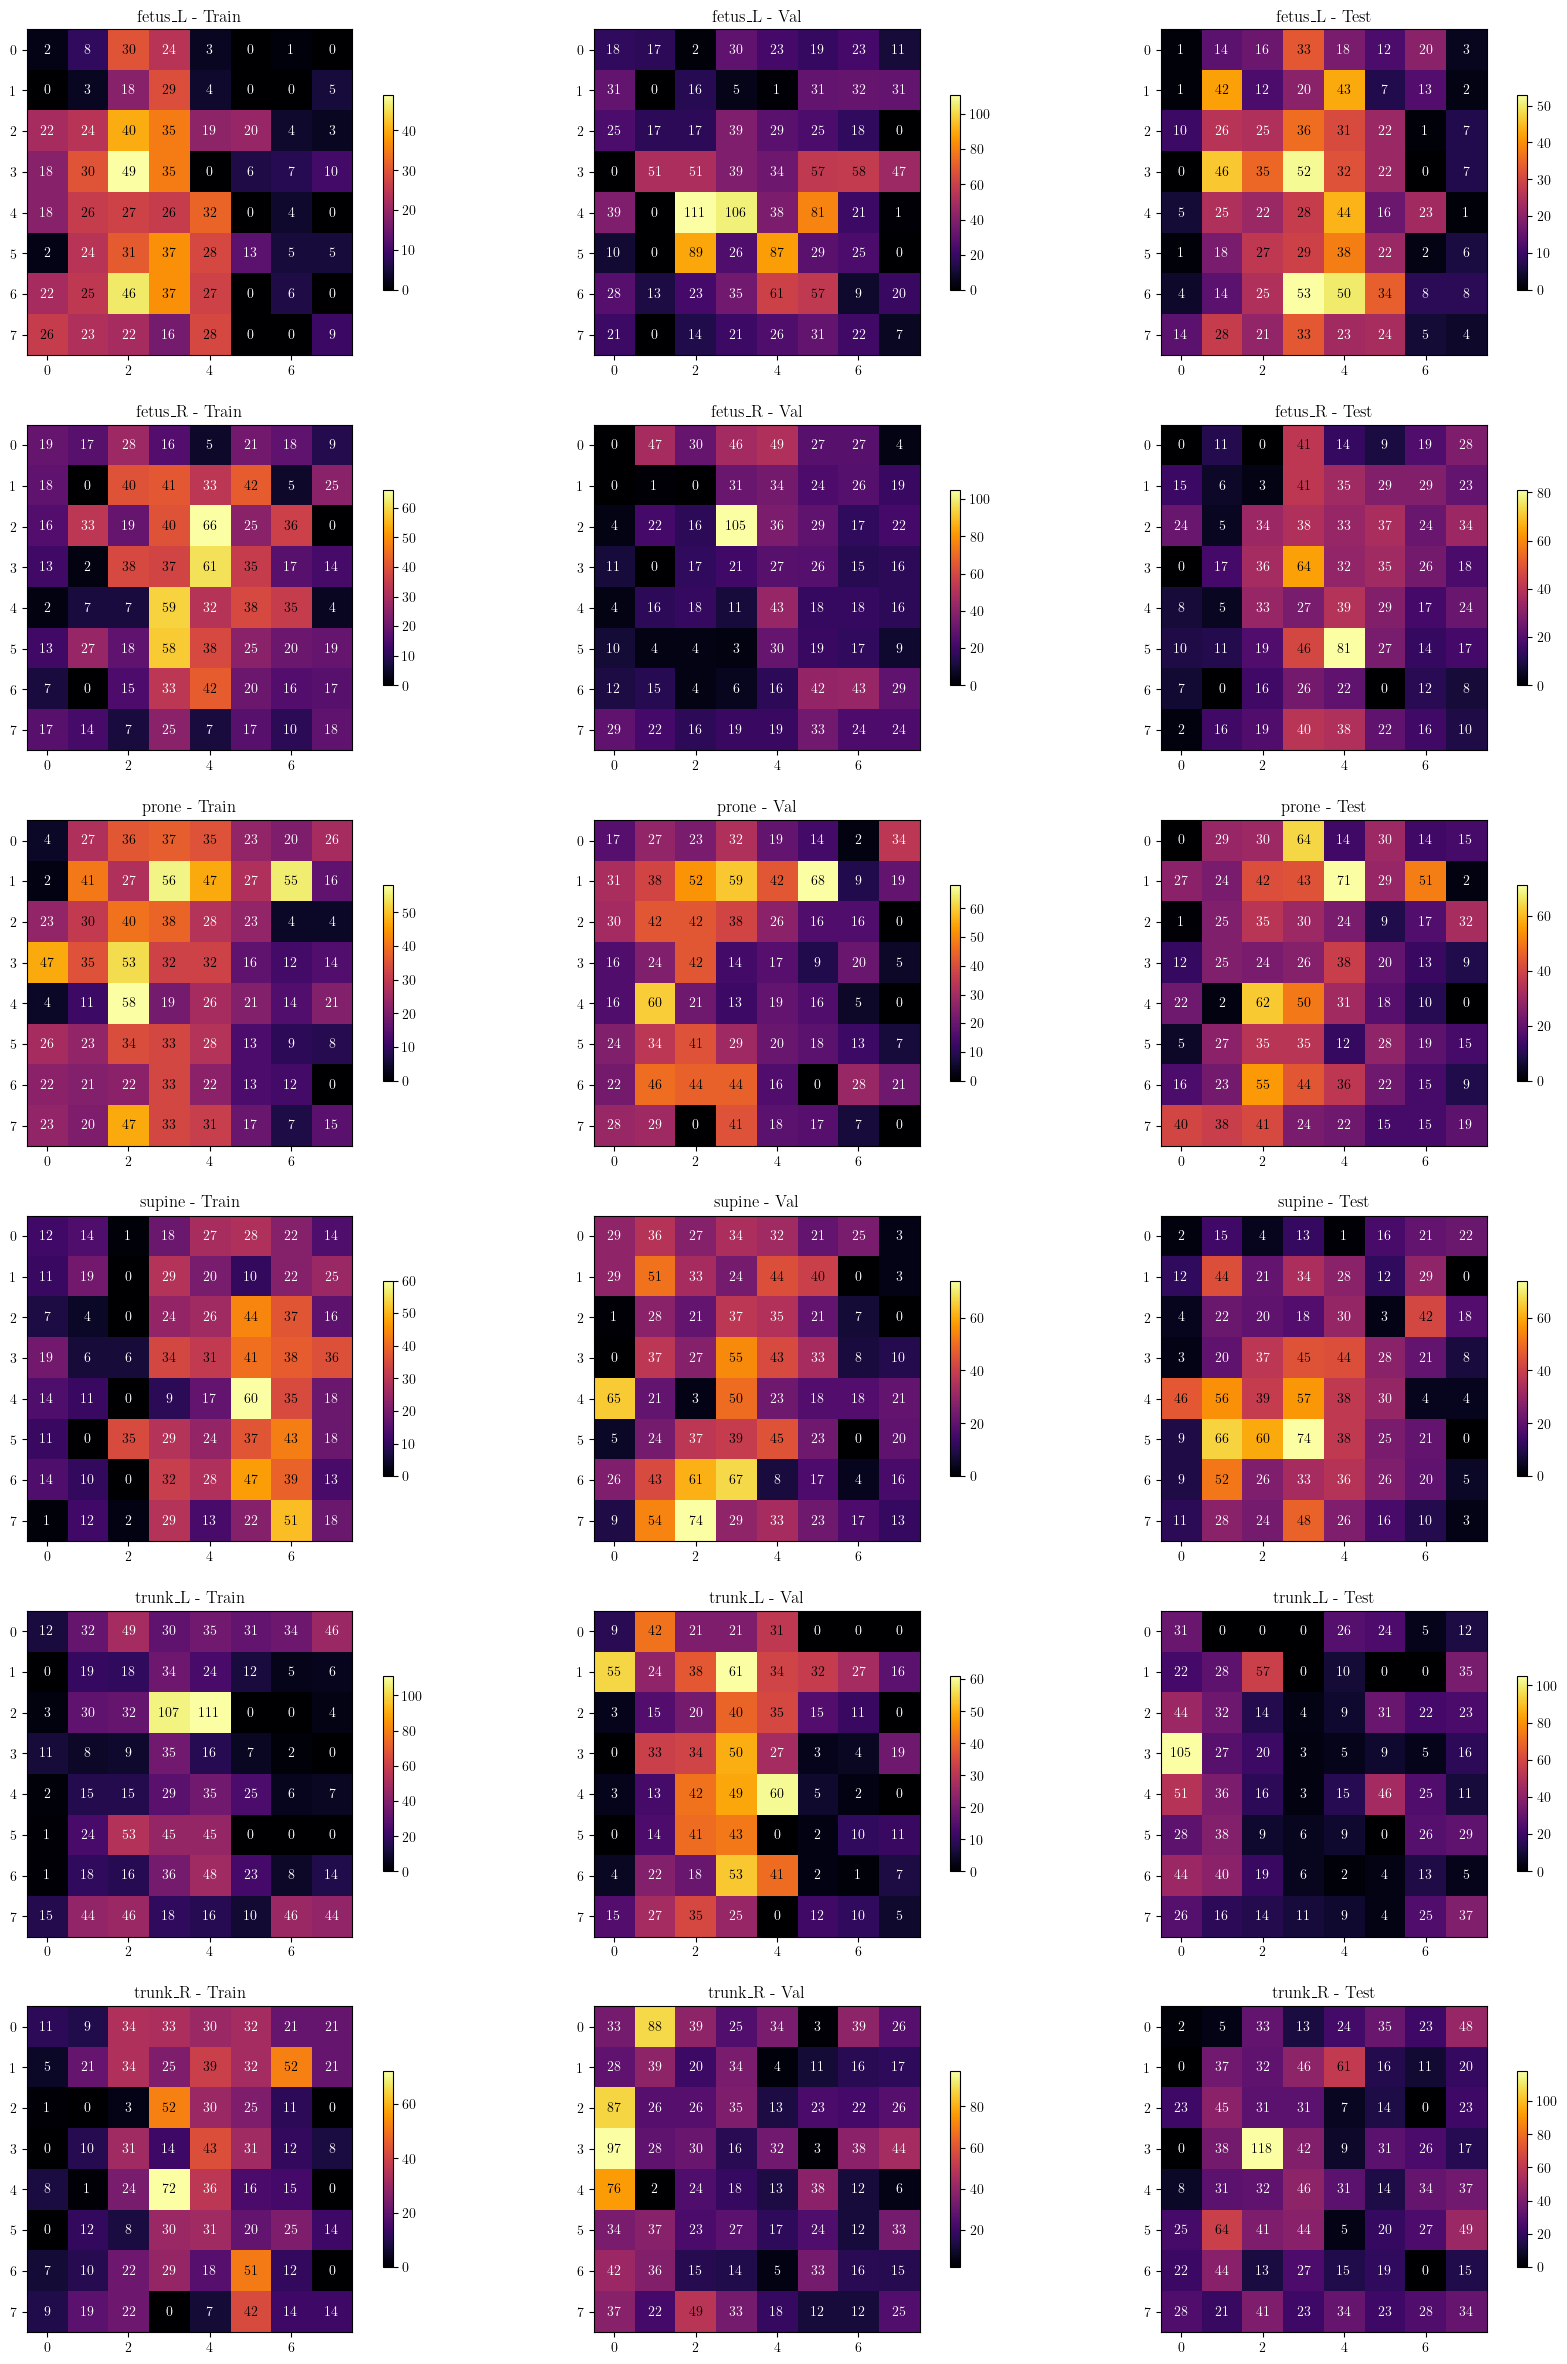

Saved: figures/split_comparison.pdf


In [43]:
# Apply indices to all three data formats
datasets = {
    'raw': data,
    'normalized': data_normalized,
    'quantized': data_q8
}

splits = {
    'train': (idx_train, labels[idx_train]),
    'val': (idx_val, labels[idx_val]),
    'test': (idx_test, labels[idx_test])
}

# Compare splits: one sample per label from each split to verify class balance
fig2 = plt.figure(figsize=(18, 24))

for i, label in enumerate(unique_labels):
    train_idx_in_split = np.where(splits['train'][1] == label)[0][0]
    val_idx_in_split = np.where(splits['val'][1] == label)[0][0]
    test_idx_in_split = np.where(splits['test'][1] == label)[0][0]
    
    train_orig_idx = splits['train'][0][train_idx_in_split]
    val_orig_idx = splits['val'][0][val_idx_in_split]
    test_orig_idx = splits['test'][0][test_idx_in_split]
    
    train_data = data_q8[train_orig_idx].reshape(8, 8)
    val_data = data_q8[val_orig_idx].reshape(8, 8)
    test_data = data_q8[test_orig_idx].reshape(8, 8)
    # Train column
    ax1 = fig2.add_subplot(6, 3, i * 3 + 1)
    im1 = ax1.imshow(train_data, cmap=CMAP_STYLE)
    ax1.set_title(f"{label} - Train")
    for r in range(8):
        for c in range(8):
            color = "black" if train_data[r, c] > train_data.max() / 2 else "white"
            ax1.text(c, r, f"{train_data[r, c]:.0f}", ha="center", va="center", color=color, fontsize=10)
    plt.colorbar(im1, ax=ax1, shrink=0.6)
    
    # Val column
    ax2 = fig2.add_subplot(6, 3, i * 3 + 2)
    im2 = ax2.imshow(val_data, cmap=CMAP_STYLE)
    ax2.set_title(f"{label} - Val")
    for r in range(8):
        for c in range(8):
            color = "black" if val_data[r, c] > val_data.max() / 2 else "white"
            ax2.text(c, r, f"{val_data[r, c]:.0f}", ha="center", va="center", color=color, fontsize=10)
    plt.colorbar(im2, ax=ax2, shrink=0.6)
    
    # Test column
    ax3 = fig2.add_subplot(6, 3, i * 3 + 3)
    im3 = ax3.imshow(test_data, cmap=CMAP_STYLE)
    ax3.set_title(f"{label} - Test")
    for r in range(8):
        for c in range(8):
            color = "black" if test_data[r, c] > test_data.max() / 2 else "white"
            ax3.text(c, r, f"{test_data[r, c]:.0f}", ha="center", va="center", color=color, fontsize=10)
    plt.colorbar(im3, ax=ax3, shrink=0.6)

plt.tight_layout(pad=2.0)
plt.savefig('figures/split_comparison.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()
print('Saved: figures/split_comparison.pdf')

## Posture Combination

lateral_L = fetus_L + trunk_L
lateral_R = fetus_R + trunk_R
supine = supine + prone

In [44]:
# Define posture combination mapping
LABEL_COMBINATION = {
    'fetus_L': 'lateral_L',
    'trunk_L': 'lateral_L',
    'fetus_R': 'lateral_R',
    'trunk_R': 'lateral_R',
    'supine': 'supine',
    'prone': 'supine',
}

# Apply mapping to all splits
for split_name in splits:
    indices, old_labels = splits[split_name]
    new_labels = np.array([LABEL_COMBINATION[label] for label in old_labels])
    splits[split_name] = (indices, new_labels)

# Update label metadata to reflect combined classes
unique_labels = np.array(['lateral_L', 'lateral_R', 'supine'])

# Print combined class distribution for verification
print('Combined class distribution:')
for label in unique_labels:
    for split_name, (_, split_labels) in splits.items():
        count = np.sum(split_labels == label)
        print(f'  {label} in {split_name}: {count}')

Combined class distribution:
  lateral_L in train: 40000
  lateral_L in val: 20000
  lateral_L in test: 40000
  lateral_R in train: 40000
  lateral_R in val: 20000
  lateral_R in test: 40000
  supine in train: 39999
  supine in val: 20000
  supine in test: 40001


### Saving the datasets


In [45]:
# Create label mapping for Verilog
label_map = {label: idx for idx, label in enumerate(unique_labels)}

# Save all datasets
for data_name, data_array in datasets.items():
    for split_name, (indices, split_labels) in splits.items():
        split_data = data_array[indices]
        
        # Save NPZ for Python/PYNQ-Z2
        np.savez(f"output/{split_name}_{data_name}.npz",
                 data=split_data, labels=split_labels)
        
        # Save HEX for Verilog (only for quantized data)
        if data_name == 'quantized':
            with open(f"output/{split_name}_{data_name}.hex", "w") as f:
                f.write(f"// {split_name.upper()} Set - uint8\n")
                f.write(f"// Samples: {len(split_data)}\n")
                f.write("// Format: 64 hex values per sample (8x8, row-major)\n\n")
                for i, (sample, label) in enumerate(zip(split_data, split_labels)):
                    hex_vals = [f"{val:02x}" for val in sample]
                    label_idx = label_map[label]
                    f.write(f"// {label} (class {label_idx})\n")
                    f.write(" ".join(hex_vals) + "\n")

print(f"\nLabel mapping: {label_map}")


Label mapping: {np.str_('lateral_L'): 0, np.str_('lateral_R'): 1, np.str_('supine'): 2}
